# 学习任务与估计器

学习目标：把一个分类问题组织成特征与目标，完成数据划分、拟合和预测，分清估计器参数、拟合属性与数据变换。

前置知识：Python 变量、函数调用与对象属性；NumPy 数组形状、切片与布尔索引；散点图。

环境准备：[课程环境与运行步骤](README.md)。使用 Python 3.12 与课程依赖，具体版本集中在环境说明中。

工作目录：本 Notebook 所在的课程目录。选择 hands-on-computing 环境中的 Python 内核，从第一个代码单元顺序运行；数据随 scikit-learn 提供，无需联网下载，只使用 CPU。

数据：Iris 鸢尾花数据，由 sklearn.datasets.load_iris 直接读入内存。本章不写出数据文件，字段与单位见第 2 节。

本章是接口导览。KNeighborsClassifier 和 StandardScaler 只用于观察调用职责，不把这里的几行库调用视为完整的算法推导或手写实现。

## 1 先说清要学习什么

一条待研究的记录称为样本，描述它的输入量称为特征；需要预测的量称为目标。监督学习使用带目标的样本，无监督学习主要从输入中寻找结构。

| 原文名称 | 中文名称／含义 | 一个具体问题 | 拟合时的目标 |
| --- | --- | --- | --- |
| Classification | 分类 | 根据测量值预测鸢尾花品种 | 已知的品种标签 |
| Regression | 回归 | 根据房屋属性预测价格 | 已知的数值价格 |
| Clustering | 聚类 | 按记录相似性形成分组 | 不提供预先确定的分组标签 |

分类与回归属于监督学习，聚类属于无监督学习。数字编码的类别仍然是类别：品种 2 不表示品种 1 的两倍。

表格型单目标任务通常把输入记为 $X\in\mathbb{R}^{n\times p}$，目标记为长度为 $n$ 的 $y$。这里 $\mathbb{R}$ 表示实数，$n$ 是样本数，$p$ 是特征数；$X$ 的每一行和 $y$ 的同一位置对应同一个样本。下面的三个房屋样本为人工构造，只演示数组组织；同一输入可以配不同任务的目标。

In [1]:
import numpy as np

# 两列依次是面积（平方米）和房间数；两种目标都按相同的房屋顺序排列。
X_demo = np.array([[50, 1], [80, 2], [120, 3]])
y_price = np.array([150.0, 240.0, 380.0])  # 合成价格，单位：万元。
y_type = np.array([0, 0, 1])  # 0、1 是人为指定的类别编号，没有倍数关系。

# 预期：输入为 (3, 2)，两种单目标数组均为 (3,)；形状不决定任务类型。
print("输入形状：", X_demo.shape)
print("回归目标形状：", y_price.shape)
print("分类目标形状：", y_type.shape)

# 预期：同一个样本的输入 [50 1]、价格 150.0、类别 0 保持对应。
print("第一个样本：", X_demo[0], y_price[0], y_type[0])

输入形状： (3, 2)
回归目标形状： (3,)
分类目标形状： (3,)
第一个样本： [50  1] 150.0 0


## 2 读入 Iris 并确认字段

库的名称是 scikit-learn，Python 导入名称是 sklearn。load_iris 返回一个类似字典、也可通过属性取值的 Bunch 对象，data 保存特征，target 保存类别编号；feature_names 和 target_names 分别解释列与类别。

| 特征原名 | 中文名称／含义 | 单位 |
| --- | --- | --- |
| sepal length | 萼片长度 | cm |
| sepal width | 萼片宽度 | cm |
| petal length | 花瓣长度 | cm |
| petal width | 花瓣宽度 | cm |

本数据包含 150 个样本、4 个数值特征，每个品种各 50 个样本，没有缺失值。编号 0、1、2 依次对应 setosa、versicolor、virginica。目标单独放在 y 中，不把品种编号再作为输入特征。这里使用 scikit-learn 随包提供的版本；小型教学数据上的表现不能代表真实应用效果。

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

# 预期：X 为 (150, 4)，y 为 (150,)；每行花的测量值与同位置品种对应。
print("特征与目标形状：", X.shape, y.shape)

# 预期：四列按萼片长、萼片宽、花瓣长、花瓣宽排列，名字均注明 cm。
print("特征顺序：", iris.feature_names)

# 预期：[0 1 2] 分别映射到 ['setosa' 'versicolor' 'virginica']。
print("类别编号与名称：", np.unique(y), iris.target_names)

# 预期：首行是 [5.1 3.5 1.4 0.2]，目标 0，对应 setosa。
print("第一朵花：", X[0], y[0], iris.target_names[y[0]])

特征与目标形状： (150, 4) (150,)
特征顺序： ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别编号与名称： [0 1 2] ['setosa' 'versicolor' 'virginica']
第一朵花： [5.1 3.5 1.4 0.2] 0 setosa


## 3 先留出没有参与拟合的数据

把部分样本保留为测试集，可以观察模型对未参与拟合样本的预测。train_test_split 同时划分 X 和 y，保持它们逐行对应；不要分别打乱特征和目标。

本例固定使用 20% 测试样本、分层抽样和随机种子 42。分层抽样按 y 的类别比例分配样本；random_state 的整数控制划分过程的随机打乱。本章配置预先确定，测试输出只作最终观察，不根据它继续选参数。

下图从分类接口角度区分拟合与预测。训练特征和目标参与 fit；测试特征交给已拟合模型的 predict，测试目标只用于评估。

![估计器流程示意：训练特征和目标用于拟合，测试特征用于预测，测试目标只参与评估](image/illustration/01-01-estimator-workflow.svg)

图：CMYK Labs 原创接口流程示意，依据 scikit-learn 的 fit 与 predict 约定绘制。箭头表示数据与调用流程；省略模型内部计算，不代表一次真实运行结果。

In [3]:
from sklearn.model_selection import train_test_split

# tr 表示训练集，te 表示测试集；传入同一次调用，保持 X 与 y 的样本配对。
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 预期：训练输入 (120, 4)、目标 (120,)；测试输入 (30, 4)、目标 (30,)。
print("训练集形状：", X_tr.shape, y_tr.shape)
print("测试集形状：", X_te.shape, y_te.shape)

# bincount 按非负整数标签统计数量；预期三类训练各 40 个，测试各 10 个。
print("训练类别计数：", np.bincount(y_tr))
print("测试类别计数：", np.bincount(y_te))

训练集形状： (120, 4) (120,)
测试集形状： (30, 4) (30,)
训练类别计数： [40 40 40]
测试类别计数： [10 10 10]


## 4 调用 fit 与 predict

估计器（estimator）是具有拟合接口的对象。对本例分类器，fit 接收训练特征和标签，在对象中保存用于预测的信息；predict 接收新的特征并返回类别，不需要传入那些样本的真实标签。

KNeighborsClassifier 是近邻分类器：概览地说，它参考附近训练样本的类别作出预测。n_neighbors=5 指定参考 5 个邻居。本例使用原始 4 列厘米测量值，只演示接口，不比较缩放方法或选择最优邻居数。

| API | 中文名称／含义 | 本例的输入与输出 |
| --- | --- | --- |
| fit | 拟合 | 输入训练 X 与 y，返回已拟合的对象自身 |
| predict | 预测 | 输入测试 X，返回每行的预测类别 |

训练完成不等于预测一定正确。下面把预测与测试目标并列显示，再统计相同的个数；这个计数只描述本次划分，不承诺新数据上有相同表现。

In [4]:
from sklearn.neighbors import KNeighborsClassifier

# 模型仅用训练数据拟合；默认 uniform 让 5 个邻居等权参与类别投票。
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_tr, y_tr)
pred = model.predict(X_te)

# 预期：30 个测试样本得到形状为 (30,) 的类别数组，元素来自 0、1、2。
print("预测形状：", pred.shape)

# 预期：两行各显示前 5 个类别，位置逐一对应；具体序列随划分变化。
print("前 5 个预测类别：", pred[:5])
print("前 5 个真实类别：", y_te[:5])

# 预期：正确数为 0 到 30 之间的整数，总数为 30；不把本次计数当作保证。
print("本次预测正确数与总数：", np.sum(pred == y_te), len(y_te))

预测形状： (30,)
前 5 个预测类别： [0 2 1 1 0]
前 5 个真实类别： [0 2 1 1 0]
本次预测正确数与总数： 30 30


## 5 分清参数与拟合属性

参数由使用者配置，例如 n_neighbors；get_params 可以查看它们。拟合属性记录从数据得到的信息，例如 classes\_ 和 n_features_in\_，scikit-learn 使用末尾下划线标识这类公开属性。

| 名称 | 中文名称／含义 | 从哪里得到 |
| --- | --- | --- |
| n_neighbors | 预测时参考的邻居个数 | 创建对象时指定 |
| classes\_ | 拟合时见过的类别 | 训练目标 |
| n_features_in\_ | 拟合输入的特征数 | 训练特征 |
| n_samples_fit\_ | 拟合使用的样本数 | 训练样本 |

统一的接口不表示每个模型拥有完全相同的属性，应以对应类文档为准。以下继续查看第 4 节拟合完成的 model，不重新训练或改动参数。

In [5]:
# 预期：配置参数仍然为 5；它不会自动变成从测试结果选出的“最佳值”。
print("邻居数参数：", model.get_params()["n_neighbors"])

# 预期：classes_ 为 [0 1 2]，拟合时使用 4 个特征和 120 个样本。
print("已知类别：", model.classes_)
print("拟合输入特征数：", model.n_features_in_)
print("拟合样本数：", model.n_samples_fit_)

邻居数参数： 5
已知类别： [0 1 2]
拟合输入特征数： 4
拟合样本数： 120


## 6 单个样本也要保留样本轴

predict 仍按“行是样本、列是特征”的二维输入约定工作。X_te[0] 取出一维的首行向量，X_te[:1] 则保留包含一行的二维矩阵。预测一个样本时应使用后者，不能让长度为 4 的向量丢掉样本轴。

预测输入还必须保持训练时的特征含义、顺序和单位；列数正确但顺序颠倒，同样会改变问题。下面仅验证对相同样本进行批量与单独调用的对应关系。

In [6]:
one = X_te[:1]
one_pred = model.predict(one)

# 预期：整数索引得到 (4,)，保留行切片得到 (1, 4)。
print("向量与单样本矩阵：", X_te[0].shape, one.shape)

# 预期：预测形状 (1,)，类别名称为 setosa、versicolor、virginica 之一。
print("单样本预测形状：", one_pred.shape)
print("单样本预测名称：", iris.target_names[one_pred])

# 预期：True；同一已拟合对象处理同一行，应与批量预测的对应位置一致。
print("与批量预测一致：", one_pred[0] == pred[0])

向量与单样本矩阵： (4,) (1, 4)
单样本预测形状： (1,)
单样本预测名称： ['setosa']
与批量预测一致： True


## 7 transform 输出变换后的特征

变换器（transformer）也有 fit，但它主要通过 transform 输出新的特征表示。以 StandardScaler 为例，fit 保存训练数据每列的均值与尺度，transform 按已保存的规则变换输入。它不输出鸢尾花品种，也不需要用测试数据再次 fit。

对一个非恒定特征，默认变换为

$$z=\frac{x-u}{s}.$$

这里 $x$ 是该特征的一个输入值，$u$ 和 $s$ 分别是训练列的均值与标准差，$z$ 是变换后的无量纲数值。StandardScaler 计算标准差时使用除以样本数的形式，即 NumPy 的 ddof=0；下面两列方差都非零。

这个独立小例子只为看清变换器的状态：人工训练数据第一列为 1、3，所以 $u=2$、$s=1$；新值 5 经变换得到 $(5-2)/1=3$。transform 保留这个标准，不让新样本修改均值。它不改变前面已经固定的鸢尾花分类实验。

In [7]:
from sklearn.preprocessing import StandardScaler

# 人工数据只用于观察接口，两列没有实际业务单位；新样本不参与 fit。
train = np.array([[1.0, 10.0], [3.0, 30.0]])
new = np.array([[5.0, 50.0]])
scaler = StandardScaler()
scaler.fit(train)
train_z = scaler.transform(train)
new_z = scaler.transform(new)

# 预期：从训练列学到 mean_=[2. 20.]、scale_=[1. 10.]。
print("训练均值：", scaler.mean_)
print("训练尺度：", scaler.scale_)

# 预期：训练变换为 [[-1. -1.], [1. 1.]]，形状仍为 (2, 2)。
print("训练特征变换：", train_z)

# 预期：新样本得到 [[3. 3.]]，形状 (1, 2)；它不必有零均值。
print("新样本变换：", new_z)

# 预期：均值仍是 [2. 20.]；transform 使用状态，不重新拟合状态。
print("变换后的训练均值：", scaler.mean_)

训练均值： [ 2. 20.]
训练尺度： [ 1. 10.]
训练特征变换： [[-1. -1.]
 [ 1.  1.]]
新样本变换： [[3. 3.]]
变换后的训练均值： [ 2. 20.]


## 8 把预测对应到实际样本

用散点图观察 30 个测试样本。横轴是花瓣长度，纵轴是花瓣宽度，单位都为 cm；颜色与点形标出真实品种，深蓝色空心圆圈出预测错误的样本。

模型实际使用了 4 个特征，这张图只投影到其中 2 个，不能把它理解为模型的完整决策边界。图沿用第 4 节保存的预测，不重新训练，也不根据测试图调整模型。

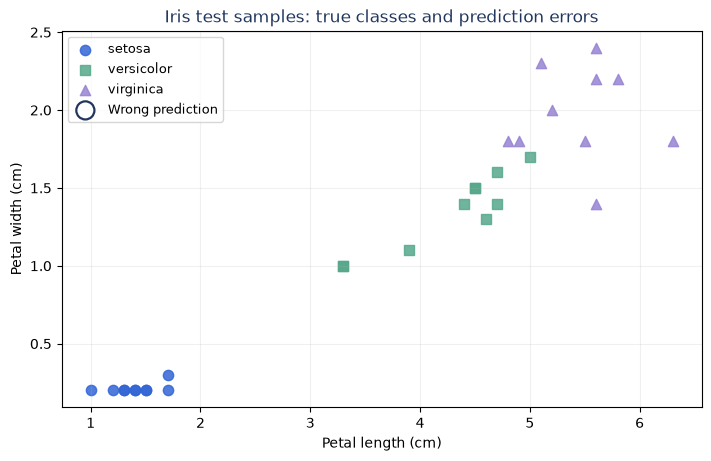

In [8]:
import matplotlib.pyplot as plt

# 每个类别同时用颜色和点形标识，避免仅依赖颜色区分。
colors = ["#3265D6", "#56A88B", "#9783D3"]
markers = ["o", "s", "^"]
fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")

# 第 2、3 列分别是花瓣长与宽；mask 选择同一真实品种的测试样本。
for label, name in enumerate(iris.target_names):
    mask = y_te == label
    ax.scatter(
        X_te[mask, 2], X_te[mask, 3], color=colors[label],
        marker=markers[label], s=55, label=name, alpha=0.85
    )

# 仅在真实预测错误的位置加空心圆；空数组也可以直接传给 scatter。
miss = pred != y_te
ax.scatter(
    X_te[miss, 2], X_te[miss, 3], facecolors="none", edgecolors="#20365F",
    s=170, linewidths=1.6, label="Wrong prediction"
)
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.set_title("Iris test samples: true classes and prediction errors", color="#20365F")
ax.legend(fontsize=9)
ax.grid(alpha=0.18)

# 预期：三种真实品种的位置分布及本次错误圈；重合点可能看起来更少。
# 所有数据来自 30 个测试样本，错误圈对应 pred != y_te，不预设错误个数。
# 本次保存的结果没有预测错误，所以散点区域没有错误圈，图例仍说明标记含义。
plt.show()

## 本章小结

（1）任务由目标含义决定。分类标签虽然可以是整数，但它们不因此变成连续数值目标。

（2）X 的行与 y 的位置对应样本，列对应特征；划分与预测都要保持这个关系，单个样本也保留二维输入。

（3）fit 根据训练数据建立状态；predict 输出预测目标；transform 输出变换后的特征。使用新数据时复用已拟合状态。

（4）配置参数和拟合属性来源不同。能成功调用接口只是起点，还要理解模型原理，并在独立数据上检验效果。

理解自查：为什么预测时不传真实标签？为什么变换测试数据时不能重新计算训练均值？

## 练习

**题 1：改变保留比例。** 使用完整 Iris 数据，单独以 test_size=0.4、stratify=y、random_state=7 做一次划分，不拟合模型。先预测四个返回数组的形状，再核对各类别计数。不要覆盖正文的 X_tr、X_te、y_tr、y_te。

**题 2：区分一行与一列。** 分别取 X_te[:1] 和 X_te[:, :1]，预测它们的形状。哪一个能直接交给当前 model？说明形状、特征数量与特征顺序各自的作用，不以故意运行报错代替解释。

**题 3：追踪变换状态。** 在不重新拟合 scaler 的前提下，把第 7 节新样本改为 [[4.0, 40.0]]。先手算，再调用 transform，并检查 scaler.mean_ 是否改变。

In [9]:
# 练习用独立变量，不覆盖正文中已经固定的训练集、测试集和模型。
X_a, X_b, y_a, y_b = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=7
)

# 预测练习：先完成题 1，再运行；按提示核对样本数、列数及类别计数。
print("练习训练形状：", X_a.shape, y_a.shape)
print("练习测试形状：", X_b.shape, y_b.shape)
print("练习训练类别计数：", np.bincount(y_a))
print("练习测试类别计数：", np.bincount(y_b))

# 预测练习：先完成题 2，再核对“一行”和“一列”保留的两个轴。
print("一行与一列的形状：", X_te[:1].shape, X_te[:, :1].shape)

# 预测练习：先完成题 3，再与手算及原来的训练均值核对。
print("修改后的新样本变换：", scaler.transform([[4.0, 40.0]]))
print("复用的训练均值：", scaler.mean_)

练习训练形状： (90, 4) (90,)
练习测试形状： (60, 4) (60,)
练习训练类别计数： [30 30 30]
练习测试类别计数： [20 20 20]
一行与一列的形状： (1, 4) (30, 1)
修改后的新样本变换： [[2. 2.]]
复用的训练均值： [ 2. 20.]


### 提示与解析

题 1 提示：150 乘以保留比例得到测试样本数；一类原有 50 个样本。解析：训练 X、y 为 (90, 4)、(90,)，测试 X、y 为 (60, 4)、(60,)；训练各类 30 个，测试各类 20 个。这个练习只核对划分规则，不使用测试表现挑选比例或种子。

题 2 提示：第一个切片作用于行，第二个同时保留所有行并截取一列。解析：形状分别为 (1, 4)、(30, 1)，当前模型需要 4 个输入特征，因此只接受前者；即便列数为 4，换列顺序也会改变每一列的含义。

题 3 提示：继续使用训练阶段的均值与尺度。解析：结果为 [[2.0, 2.0]]，均值仍是 [2.0, 20.0]；只执行 transform 不会用新样本更新这组状态。

## 参考与引用来源

（1）**scikit-learn 官方文档（1.9.1）。** [Getting Started：Fitting and predicting、Transformers and pre-processors、Model evaluation](https://scikit-learn.org/stable/getting_started.html) 支持任务、X/y 组织和接口职责；[load_iris：返回字段](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) 与 [Toy datasets §9.1.1 Iris plants dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset) 支持数据规模、列顺序、单位、类别和适用范围；[train_test_split：参数及返回顺序](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) 支持同步划分、随机状态与分层；[KNeighborsClassifier：Parameters、Attributes、fit、predict、get_params](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) 支持近邻分类器的接口与观察属性；[Glossary：attribute](https://scikit-learn.org/stable/glossary.html#term-attribute) 支持拟合属性的命名；[StandardScaler：定义、Attributes、Notes、fit、transform](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) 支持逐列标准化、ddof=0 与状态复用；[Common pitfalls §12.2 Data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) 支持先划分、仅训练数据参与拟合及不以测试集调参。本章流程图由 CMYK Labs 依据上述接口约定原创绘制。

（2）**NumPy 官方文档（2.5）。** [Indexing on ndarrays：Basic indexing、Boolean array indexing](https://numpy.org/doc/stable/user/basics.indexing.html) 支持样本切片与绘图掩码；[numpy.bincount](https://numpy.org/doc/stable/reference/generated/numpy.bincount.html) 支持非负整数类别计数。

（3）**Matplotlib 官方文档（3.11.2）。** [Axes.scatter：x/y、marker、s、edgecolors 参数](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html) 支持测试样本散点与错误圈标记。